# Spark MLlib Taxi Demand Demo

This notebook is a small ML demo for the NYC taxi demand architecture. It can read the Iceberg ML table for the full project pipeline, or a portable Parquet export for teammates who do not have the Iceberg warehouse.

**Goal:** predict `trip_count` from pickup source, pickup zone, month, day of week, hour, and weekend flag.

## Demo Outline

1. Start Spark.
2. Choose Iceberg or portable Parquet input.
3. Load the taxi demand ML dataset.
4. Prepare simple ML features.
5. Train Linear Regression, Random Forest, and Gradient-Boosted Trees.
6. Compare RMSE, MAE, and R2.
7. Show predictions from the best model.

The notebook intentionally stops at model evaluation. The Streamlit/DuckDB serving step is part of the application layer, not this training demo.

## 1. Start Spark

The project source of truth is the Iceberg table. This cell loads the Iceberg Spark runtime package before Spark starts.

If you are running the notebook from VS Code on your Mac, Docker must expose both HDFS ports:

- NameNode RPC: `localhost:9000`
- DataNode transfer: `localhost:9866`

If Spark was already started with different settings, restart the notebook kernel before running this cell again.

In [17]:
from pathlib import Path

from pyspark import SparkContext
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor, LinearRegression, RandomForestRegressor
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

ICEBERG_PACKAGE = "org.apache.iceberg:iceberg-spark-runtime-3.5_2.12:1.5.2"
RUNNING_IN_DOCKER = Path("/workspace").exists()

ICEBERG_WAREHOUSE = (
    "hdfs://namenode:9000/user/data/warehouse"
    if RUNNING_IN_DOCKER
    else "hdfs://localhost:9000/user/data/warehouse"
)
ML_TABLE = "nyc.taxi_demand_ml"
PORTABLE_PARQUET_PATH = (
    "/workspace/output/taxi_demand_ml_parquet"
    if RUNNING_IN_DOCKER
    else "output/taxi_demand_ml_parquet"
)

# Use "iceberg" for the project pipeline, or "parquet" for a teammate-friendly export.
INPUT_MODE = "parquet"
# INPUT_MODE = "iceberg"

# If this cell is rerun after a failed Spark startup, force Spark to rebuild with the package/config below.
active_session = SparkSession.getActiveSession()
if active_session is not None:
    active_session.stop()
elif SparkContext._active_spark_context is not None:
    SparkContext._active_spark_context.stop()

spark = (
    SparkSession.builder
    .appName("Spark MLlib Taxi Demand Demo")
    .master("local[*]")
    .config("spark.jars.packages", ICEBERG_PACKAGE)
    .config("spark.sql.catalog.nyc", "org.apache.iceberg.spark.SparkCatalog")
    .config("spark.sql.catalog.nyc.type", "hadoop")
    .config("spark.sql.catalog.nyc.warehouse", ICEBERG_WAREHOUSE)
    .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
    .config("spark.sql.shuffle.partitions", "12")
    .config("spark.default.parallelism", "12")
    .config("spark.hadoop.dfs.client.use.datanode.hostname", "false" if RUNNING_IN_DOCKER else "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print(f"Input mode: {INPUT_MODE}")
print(f"Iceberg warehouse: {ICEBERG_WAREHOUSE}")

Spark version: 3.5.0
Input mode: parquet
Iceberg warehouse: hdfs://localhost:9000/user/data/warehouse


## Optional: Create a Portable Parquet Export

Run this cell only if you have the Iceberg table and want to share the demo dataset. Send your teammate the exported folder, not random data files from the Iceberg warehouse.

A clean Parquet export has the rows and schema the ML demo needs. The Iceberg warehouse also contains table metadata and manifests, so copying only warehouse parquet files is fragile.

In [18]:
# Uncomment and run this once to create a portable dataset for teammates.
# (
#     spark.read.table(ML_TABLE)
#     .coalesce(4)
#     .write
#     .mode("overwrite")
#     .parquet(PORTABLE_PARQUET_PATH)
# )
# print(f"Wrote portable Parquet export to {PORTABLE_PARQUET_PATH}")


## 2. Load the ML Dataset

In `iceberg` mode, the notebook reads `nyc.taxi_demand_ml`. In `parquet` mode, it reads the portable Parquet export from `PORTABLE_PARQUET_PATH`.

In [19]:
required_columns = [
    "source_id",
    "source_name",
    "PULocationID",
    "pickup_year",
    "pickup_month",
    "pickup_day_of_week",
    "pickup_hour",
    "is_weekend",
    "trip_count",
]

if INPUT_MODE == "iceberg":
    raw_df = spark.read.table(ML_TABLE)
    input_description = ML_TABLE
elif INPUT_MODE == "parquet":
    raw_df = spark.read.parquet(PORTABLE_PARQUET_PATH)
    input_description = PORTABLE_PARQUET_PATH
else:
    raise ValueError('INPUT_MODE must be "iceberg" or "parquet"')

missing_columns = [column for column in required_columns if column not in raw_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

row_count = raw_df.count()
if row_count == 0:
    raise ValueError(f"No rows found in {input_description}")

print(f"Loaded {row_count:,} rows from {input_description}")
raw_df.select(required_columns).printSchema()
raw_df.select(required_columns).show(5, truncate=False)

Loaded 9,266,295 rows from output/taxi_demand_ml_parquet
root
 |-- source_id: long (nullable = true)
 |-- source_name: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- pickup_year: long (nullable = true)
 |-- pickup_month: long (nullable = true)
 |-- pickup_day_of_week: long (nullable = true)
 |-- pickup_hour: long (nullable = true)
 |-- is_weekend: boolean (nullable = true)
 |-- trip_count: long (nullable = true)

+---------+-----------+------------+-----------+------------+------------------+-----------+----------+----------+
|source_id|source_name|PULocationID|pickup_year|pickup_month|pickup_day_of_week|pickup_hour|is_weekend|trip_count|
+---------+-----------+------------+-----------+------------+------------------+-----------+----------+----------+
|0        |yellow     |249         |2023       |4           |1                 |23         |true      |57        |
|0        |yellow     |238         |2023       |5           |2                 |2          |false 

## 3. Prepare ML Features

Spark MLlib expects a numeric `features` vector and a numeric `label`. The boolean weekend flag is converted to `0` or `1` so it can be included in the feature vector.


In [20]:
feature_cols = [
    "source_id",
    "PULocationID",
    "pickup_month",
    "pickup_day_of_week",
    "pickup_hour",
    "is_weekend_int",
]

dataset = (
    raw_df
    .select(
        F.col("source_id").cast("int"),
        F.col("source_name").cast("string"),
        F.col("PULocationID").cast("long"),
        F.col("pickup_year").cast("int"),
        F.col("pickup_month").cast("int"),
        F.col("pickup_day_of_week").cast("int"),
        F.col("pickup_hour").cast("int"),
        F.col("is_weekend").cast("boolean"),
        F.col("trip_count").cast("double").alias("trip_count"),
    )
    .dropna(subset=[
        "source_id",
        "PULocationID",
        "pickup_year",
        "pickup_month",
        "pickup_day_of_week",
        "pickup_hour",
        "is_weekend",
        "trip_count",
    ])
    .withColumn("is_weekend_int", F.col("is_weekend").cast("int"))
    .withColumn("label", F.col("trip_count"))
)

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip",
)

print("Feature columns:")
for column in feature_cols:
    print(f"- {column}")


Feature columns:
- source_id
- PULocationID
- pickup_month
- pickup_day_of_week
- pickup_hour
- is_weekend_int


## 4. Split Train and Test Data

Following the architecture summary, the model trains on 2023-2024 data and tests on 2025 data.


In [21]:
train_years = [2023, 2024]
test_year = 2025

train_df = dataset.filter(F.col("pickup_year").isin(train_years)).cache()
test_df = dataset.filter(F.col("pickup_year") == test_year).cache()

train_count = train_df.count()
test_count = test_df.count()

if train_count == 0:
    raise ValueError(f"No training rows found for years: {train_years}")
if test_count == 0:
    raise ValueError(f"No test rows found for year: {test_year}")

print(f"Train years: {train_years}")
print(f"Test year: {test_year}")
print(f"Train rows: {train_count:,}")
print(f"Test rows: {test_count:,}")


Train years: [2023, 2024]
Test year: 2025
Train rows: 6,079,822
Test rows: 3,186,473


## 5. Train Spark MLlib Models

The three models give a simple comparison: a linear baseline, a random forest, and gradient-boosted trees.


In [22]:
model_specs = [
    (
        "LinearRegression",
        LinearRegression(
            featuresCol="features",
            labelCol="label",
            predictionCol="prediction",
            maxIter=50,
            regParam=0.1,
            elasticNetParam=0.0,
        ),
    ),
    (
        "RandomForestRegressor",
        RandomForestRegressor(
            featuresCol="features",
            labelCol="label",
            predictionCol="prediction",
            numTrees=30,
            maxDepth=8,
            seed=42,
        ),
    ),
#     (
#         "GBTRegressor",
#         GBTRegressor(
#             featuresCol="features",
#             labelCol="label",
#             predictionCol="prediction",
#             maxIter=30,
#             maxDepth=5,
#             seed=42,
#         ),
#     ),
]

metric_names = ["rmse", "mae", "r2"]
evaluators = {
    metric: RegressionEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric,
    )
    for metric in metric_names
}

trained_models = {}
evaluation_rows = []

for model_name, estimator in model_specs:
    print(f"Training {model_name}...")
    pipeline = Pipeline(stages=[assembler, estimator])
    model = pipeline.fit(train_df)
    predictions = model.transform(test_df)

    metrics = {
        metric: float(evaluator.evaluate(predictions))
        for metric, evaluator in evaluators.items()
    }
    evaluation_rows.append({"model": model_name, **metrics})
    trained_models[model_name] = model

    print(
        f"{model_name}: "
        f"RMSE={metrics['rmse']:.4f}, "
        f"MAE={metrics['mae']:.4f}, "
        f"R2={metrics['r2']:.4f}"
    )


Training LinearRegression...
LinearRegression: RMSE=101.1086, MAE=67.7253, R2=0.1528
Training RandomForestRegressor...
RandomForestRegressor: RMSE=94.9534, MAE=62.3275, R2=0.2528


## 6. Compare Metrics

Lower RMSE and MAE are better. Higher R2 is better. The best model below is selected by lowest RMSE.


In [23]:
metrics_df = spark.createDataFrame(evaluation_rows)
metrics_df.orderBy("rmse").show(truncate=False)

best_result = min(evaluation_rows, key=lambda row: row["rmse"])
best_model_name = best_result["model"]
best_model = trained_models[best_model_name]

print(f"Best model by RMSE: {best_model_name}")


+-----------------+---------------------+-------------------+-----------------+
|mae              |model                |r2                 |rmse             |
+-----------------+---------------------+-------------------+-----------------+
|62.32753481459008|RandomForestRegressor|0.25284519323318155|94.95335535125506|
|67.7252556810755 |LinearRegression     |0.15283921043674265|101.1085638653774|
+-----------------+---------------------+-------------------+-----------------+

Best model by RMSE: RandomForestRegressor


In [49]:
print(f"""
Best Model: {best_model_name}
RMSE: {best_result['rmse']}
MAE: {best_result['mae']}
R2: {best_result['r2']}
""")


Best Model: RandomForestRegressor
RMSE: 94.95335535125506
MAE: 62.32753481459008
R2: 0.25284519323318155



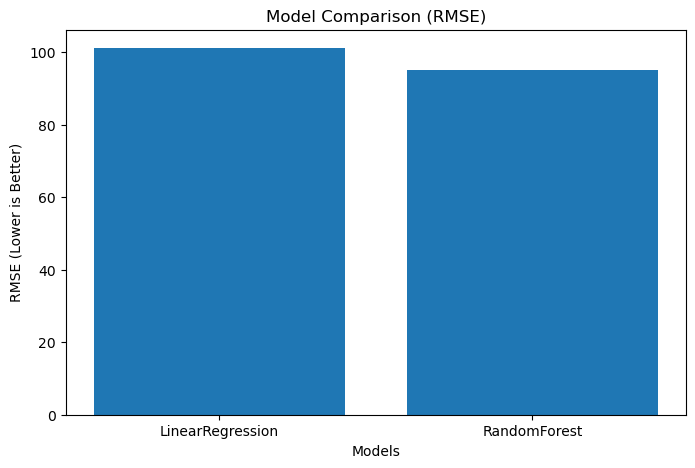

In [41]:
#Model comparison visulaization
import matplotlib.pyplot as plt

models = ["LinearRegression", "RandomForest"]
rmse = [101.10, 94.95]   # use YOUR actual values
mae = [67.72, 62.33]

plt.figure(figsize=(8,5))
plt.bar(models, rmse)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE (Lower is Better)")
plt.xlabel("Models")
plt.show()

In [34]:
#Save best model
best_model.write().overwrite().save("output/best_model_rf")

print("Best model saved successfully!")

Best model saved successfully!


## 7. Show Sample Predictions

These rows show the model output next to the actual 2025 demand count. They are sorted by pickup zone and time so the output is easy to read during a demo.


In [47]:
sample_predictions = (
    best_model
    .transform(test_df)
    .select(
        "source_name",
        "PULocationID",
        "pickup_year",
        "pickup_month",
        "pickup_day_of_week",
        "pickup_hour",
        "is_weekend",
        F.col("trip_count").alias("actual_trip_count"),
        F.round(F.col("prediction"), 2).alias("prediction"),
    )
    .orderBy("source_name", "PULocationID", "pickup_month", "pickup_day_of_week", "pickup_hour")
)

sample_predictions.show(10, truncate=False)

# Save sample predictions 
sample_predictions.limit(1000).toPandas().to_csv("output/sample_predictions.csv", index=False)

print("Sample predictions saved!")


+-----------+------------+-----------+------------+------------------+-----------+----------+-----------------+----------+
|source_name|PULocationID|pickup_year|pickup_month|pickup_day_of_week|pickup_hour|is_weekend|actual_trip_count|prediction|
+-----------+------------+-----------+------------+------------------+-----------+----------+-----------------+----------+
|hvfhv      |1           |2025       |1           |4                 |9          |false     |1.0              |115.7     |
|hvfhv      |1           |2025       |2           |1                 |14         |true      |1.0              |108.89    |
|hvfhv      |1           |2025       |3           |7                 |4          |true      |1.0              |63.79     |
|hvfhv      |1           |2025       |3           |7                 |4          |true      |1.0              |63.79     |
|hvfhv      |1           |2025       |8           |4                 |21         |false     |1.0              |116.56    |
|hvfhv      |1  

In [35]:
#predictions for full dataset
full_predictions = best_model.transform(dataset)

full_predictions = full_predictions.select(
    "source_name",
    "PULocationID",
    "pickup_year",
    "pickup_month",
    "pickup_day_of_week",
    "pickup_hour",
    "is_weekend",
    F.round(F.col("prediction"), 2).alias("predicted_trip_count")
)

full_predictions.show(10, truncate=False)

+-----------+------------+-----------+------------+------------------+-----------+----------+--------------------+
|source_name|PULocationID|pickup_year|pickup_month|pickup_day_of_week|pickup_hour|is_weekend|predicted_trip_count|
+-----------+------------+-----------+------------+------------------+-----------+----------+--------------------+
|yellow     |249         |2023       |4           |1                 |23         |true      |48.75               |
|yellow     |238         |2023       |5           |2                 |2          |false     |16.17               |
|yellow     |130         |2023       |5           |2                 |2          |false     |17.17               |
|yellow     |170         |2023       |5           |2                 |3          |false     |15.23               |
|yellow     |100         |2023       |5           |2                 |4          |false     |12.36               |
|yellow     |137         |2023       |5           |2                 |5         

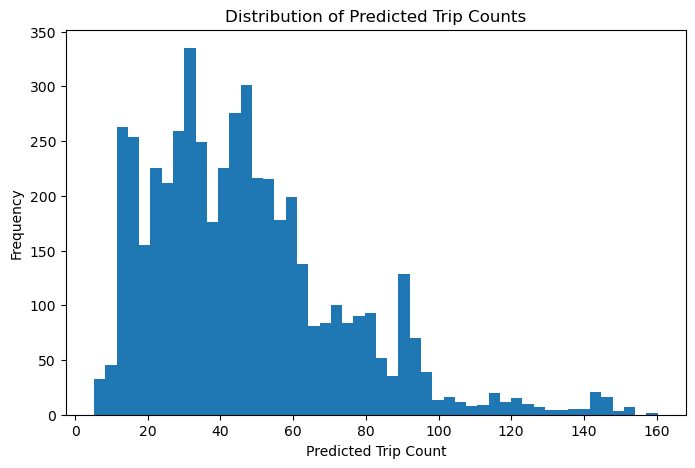

In [44]:
#predicted trip counts distribution
pdf = full_predictions.select("predicted_trip_count") \
    .limit(5000) \
    .toPandas()

plt.figure(figsize=(8,5))
plt.hist(pdf["predicted_trip_count"], bins=50)
plt.title("Distribution of Predicted Trip Counts")
plt.xlabel("Predicted Trip Count")
plt.ylabel("Frequency")
plt.show()

In [38]:
#Demand levels
full_predictions = full_predictions.withColumn(
    "demand_level",
    F.when(F.col("predicted_trip_count") < 20, "low")
     .when(F.col("predicted_trip_count") < 50, "medium")
     .when(F.col("predicted_trip_count") < 100, "high")
     .otherwise("very_high")
)

In [39]:
full_predictions.show(10, truncate=False)

+-----------+------------+-----------+------------+------------------+-----------+----------+--------------------+------------+
|source_name|PULocationID|pickup_year|pickup_month|pickup_day_of_week|pickup_hour|is_weekend|predicted_trip_count|demand_level|
+-----------+------------+-----------+------------+------------------+-----------+----------+--------------------+------------+
|yellow     |249         |2023       |4           |1                 |23         |true      |48.75               |medium      |
|yellow     |238         |2023       |5           |2                 |2          |false     |16.17               |low         |
|yellow     |130         |2023       |5           |2                 |2          |false     |17.17               |low         |
|yellow     |170         |2023       |5           |2                 |3          |false     |15.23               |low         |
|yellow     |100         |2023       |5           |2                 |4          |false     |12.36      

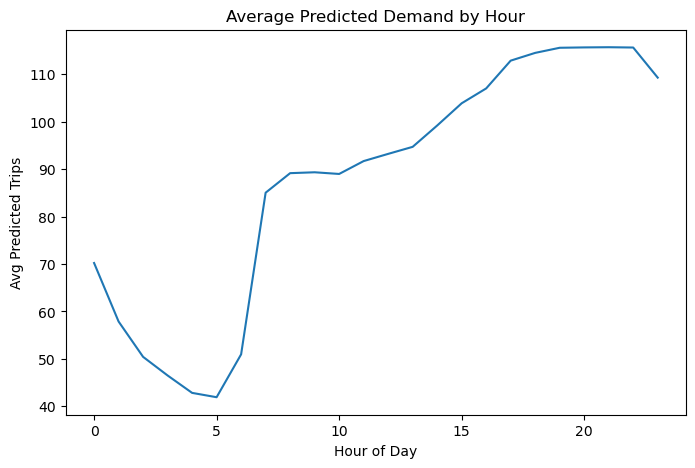

In [45]:
#Visualizing avg predicted demand by hour
hourly_pdf = full_predictions.groupBy("pickup_hour") \
    .avg("predicted_trip_count") \
    .orderBy("pickup_hour") \
    .toPandas()

plt.figure(figsize=(8,5))
plt.plot(hourly_pdf["pickup_hour"], hourly_pdf["avg(predicted_trip_count)"])
plt.title("Average Predicted Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Predicted Trips")
plt.show()

In [40]:
full_predictions.write.mode("overwrite").parquet("output/final_predictions")

print("Final predictions saved!")

Final predictions saved!


## 8. Stop Spark

Stop the Spark session when the demo is finished so local resources are released.


In [11]:
train_df.unpersist()
test_df.unpersist()
spark.stop()
